# Exact negative-pressure HAR transfer to the backward LSEG window

**Objective.** Test the unchanged FNSPID market negative-pressure hysteresis
rule on the earlier Reuters/LSEG block after extending the local S&P 500
opening-price history.

The signal inputs and their activation rate were inspected before the older
index returns were acquired. The design was then committed as `12086d5`.
This is a bounded historical robustness test, not prospective confirmation.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.plots import CATEGORICAL, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    build_market_negative_pressure,
    build_market_risk_exposure,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    CONTROL_FEATURES,
    LogVarianceModel,
    VolatilityTargetConfig,
    backtest_single_asset_exposure,
    build_volatility_frame,
    build_volatility_target_exposure,
    paired_circular_block_mean,
    predict_variance,
)

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260812
BOUNDARY = pd.Timestamp("2025-10-27")
N_FIRMS = 33
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
CONFIG = VolatilityTargetConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=20,
    bootstrap_replications=4_999,
    random_seed=SEED,
)

OUTPUT = ROOT / "final_experiments/outputs/73_lseg_negative_pressure_har_backward_transfer"
SPEC_PATH = ROOT / "final_experiments/frozen_specs/lseg_negative_pressure_har_backward_transfer_v1_20260812.json"
BACKWARD_PATH = ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/backward_finbert_firm_open.parquet"
COEFFICIENT_PATH = ROOT / "final_experiments/outputs/21_fnspid_sentiment_volatility_target/model_coefficients.csv"
HAR_MANIFEST_PATH = COEFFICIENT_PATH.with_name("manifest.json")
NOTEBOOK72_SPEC_PATH = ROOT / "final_experiments/frozen_specs/lseg_negative_pressure_har_transfer_v1_20260812.json"
PRICE_PATH = ROOT / "Data/derived/prices/lseg_sp500_20230101_20251027.csv"
PRICE_MANIFEST_PATH = PRICE_PATH.with_suffix(".manifest.json")
OUTPUT.mkdir(parents=True, exist_ok=True)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def bh_qvalues(p_values: list[float] | np.ndarray) -> np.ndarray:
    values = np.asarray(p_values, dtype=float)
    if np.any(~np.isfinite(values)) or np.any((values < 0) | (values > 1)):
        raise ValueError("BH p-values must be finite and in [0, 1]")
    order = np.argsort(values, kind="mergesort")
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0.0, 1.0)
    return adjusted


def annualized_sharpe(values: pd.Series) -> float:
    volatility = float(values.std(ddof=1))
    return float(np.sqrt(252) * values.mean() / volatility) if volatility > 0 else float("nan")


def max_drawdown(values: pd.Series) -> float:
    equity = (1.0 + values).cumprod().to_numpy(dtype=float)
    peak = np.maximum.accumulate(equity)
    return float(np.min(equity / peak - 1.0))


def paired_estimands(
    challenger: pd.DataFrame,
    baseline: pd.DataFrame,
    *,
    comparison: str,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    paired = (
        challenger[["session_date", "net_return"]]
        .rename(columns={"net_return": "challenger_net"})
        .merge(
            baseline[["session_date", "net_return"]].rename(
                columns={"net_return": "baseline_net"}
            ),
            on="session_date",
            validate="1:1",
        )
        .sort_values("session_date", kind="mergesort")
        .reset_index(drop=True)
    )
    paired["net_difference"] = paired["challenger_net"] - paired["baseline_net"]
    paired["downside_reduction"] = (
        np.minimum(paired["baseline_net"], 0.0) ** 2
        - np.minimum(paired["challenger_net"], 0.0) ** 2
    )
    rows = []
    for offset, (estimand, column) in enumerate(
        (
            ("challenger minus baseline net return", "net_difference"),
            ("baseline minus challenger downside squared return", "downside_reduction"),
        )
    ):
        result = paired_circular_block_mean(
            paired[column],
            block_length=CONFIG.bootstrap_block_length,
            replications=CONFIG.bootstrap_replications,
            seed=seed + offset,
        )
        rows.append({"comparison": comparison, "estimand": estimand, **result})
    return pd.DataFrame(rows), paired


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT}")
print(f"spec:   {SPEC_PATH.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/73_lseg_negative_pressure_har_backward_transfer
spec:   final_experiments/frozen_specs/lseg_negative_pressure_har_backward_transfer_v1_20260812.json


## Frozen design and input audit

The pre-outcome freeze fixes the 1.5/0.5 hysteresis, 0.25 risk-off multiplier,
2011–2019 FNSPID HAR coefficients, 2 bps/side costs, paired block bootstrap,
exposure-matched control and circular timing placebo. The historical Reuters
block and the recent Reuters block remain separate.

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_historical_index_return_acquisition":
    raise ValueError("unexpected frozen-spec status")

expected_known_hashes = {
    BACKWARD_PATH: spec["inputs_known_at_freeze"]["backward_finbert_firm_open"]["sha256"],
    COEFFICIENT_PATH: spec["inputs_known_at_freeze"]["frozen_har_coefficients"]["sha256"],
    HAR_MANIFEST_PATH: spec["inputs_known_at_freeze"]["frozen_har_manifest"]["sha256"],
    NOTEBOOK72_SPEC_PATH: spec["inputs_known_at_freeze"]["notebook_72_spec"]["sha256"],
}
required_paths = (*expected_known_hashes, PRICE_PATH, PRICE_MANIFEST_PATH)
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"missing required inputs: {missing_paths}")
for path, expected in expected_known_hashes.items():
    if sha256(path) != expected:
        raise ValueError(f"frozen input hash mismatch: {path}")

price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
if price_manifest["file"]["sha256"] != sha256(PRICE_PATH):
    raise ValueError("S&P 500 price file does not match its manifest")
if price_manifest.get("provider") != "lseg":
    raise ValueError("historical index prices are not from LSEG")
if price_manifest.get("rics", {}).get("^GSPC") != ".SP500":
    raise ValueError("expected the LSEG .SP500 index series")
if price_manifest.get("requested_start") != spec["price_acquisition"]["requested_start"]:
    raise ValueError("price start differs from the frozen request")
if price_manifest.get("requested_end") != spec["price_acquisition"]["requested_end"]:
    raise ValueError("price end differs from the frozen request")

input_audit = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(ROOT)),
            "sha256": sha256(path),
            "bytes": path.stat().st_size,
            "known_at_freeze": path in expected_known_hashes,
        }
        for path in required_paths
    ]
)
display(input_audit)

,path,sha256,bytes,known_at_freeze
0,final_experiments/outputs/67_lseg_gemma_finber...,745e6cba49c6dc6e256f9a6495b39eee66679231d162b5...,1331578,True
1,final_experiments/outputs/21_fnspid_sentiment_...,ea005d6f440ab04814945e17aff902e6200ff3efa2994e...,361,True
2,final_experiments/outputs/21_fnspid_sentiment_...,33bd7ec5a7e9caac6dff56a72b15459889853ca897ff6e...,7749,True
3,final_experiments/frozen_specs/lseg_negative_p...,45cc68cfd70a836c22eb4ed586235335326cc7914d7f4e...,5121,True
4,Data/derived/prices/lseg_sp500_20230101_202510...,18f79a30c8946fa86ae7aec83489fb0ef5d571a5c70641...,47161,False
5,Data/derived/prices/lseg_sp500_20230101_202510...,ed3117be4930c67b0aab7d9353dea68169cc870b4debee...,1594,False


In [3]:
prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = prices["session_date"].dt.normalize()
prices = prices.sort_values("session_date", kind="mergesort").reset_index(drop=True)
if set(prices["symbol"]) != {"^GSPC"}:
    raise ValueError("historical price export contains an unexpected symbol")
if prices["session_date"].duplicated().any():
    raise ValueError("duplicate index price sessions")
if prices["open"].isna().any() or prices["open"].le(0).any():
    raise ValueError("index opens must be finite and positive")
prices["gross_return"] = prices["open"].shift(-1) / prices["open"] - 1.0

backward = pd.read_parquet(BACKWARD_PATH)
backward["session_date"] = pd.to_datetime(backward["session_date"]).dt.normalize()
backward = backward.loc[backward["session_date"].lt(BOUNDARY)].copy()
if backward.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate backward firm-open rows")
if backward["symbol"].nunique() != N_FIRMS:
    raise ValueError("backward FinBERT panel does not contain the frozen 33 firms")

decision_sessions = pd.DatetimeIndex(sorted(backward["session_date"].unique()))
expected_window = spec["decision_window"]
if len(decision_sessions) != expected_window["expected_sessions"]:
    raise ValueError("backward session count differs from the freeze")
if decision_sessions.min() != pd.Timestamp(expected_window["expected_first_session"]):
    raise ValueError("backward first session differs from the freeze")
if decision_sessions.max() != pd.Timestamp(expected_window["expected_last_session"]):
    raise ValueError("backward last session differs from the freeze")

counts = backward.groupby("session_date")["symbol"].nunique().reindex(decision_sessions, fill_value=0)
complete_sessions = counts.index[counts.eq(N_FIRMS)]
if len(complete_sessions) != expected_window["expected_complete_33_firm_sessions"]:
    raise ValueError("complete-session count differs from the freeze")
complete_firm_open = backward.loc[backward["session_date"].isin(complete_sessions)].copy()
complete_firm_open["n"] = complete_firm_open["unique_headline_count"].astype(float)

pressure = build_market_negative_pressure(
    complete_firm_open,
    decision_sessions,
    trailing_window=spec["sentiment_rule"]["trailing_window_sessions"],
    min_periods=spec["sentiment_rule"]["minimum_prior_observations"],
)
state = build_market_risk_exposure(
    pressure,
    mode="hysteresis",
    entry_z=spec["sentiment_rule"]["entry_z"],
    exit_z=spec["sentiment_rule"]["exit_z"],
    risk_exposure=spec["sentiment_rule"]["risk_off_multiplier"],
)
state["risk_off_entry"] = state["risk_off"] & ~state["risk_off"].shift(fill_value=False)

feasibility = spec["input_only_feasibility_observed_before_returns"]
if int(state["risk_off"].sum()) != feasibility["risk_off_sessions"]:
    raise ValueError("risk-off count no longer reproduces the pre-outcome audit")
if int(state["risk_off_entry"].sum()) != feasibility["risk_off_entries"]:
    raise ValueError("risk-off entry count no longer reproduces the pre-outcome audit")

price_join = pd.DataFrame({"session_date": decision_sessions}).merge(
    prices[["session_date", "gross_return"]],
    on="session_date",
    how="left",
    validate="1:1",
)
if price_join["gross_return"].isna().any():
    raise ValueError("one or more backward sessions lack a next-open index return")

pressure_audit = pd.DataFrame(
    [
        {
            "decision_sessions": len(decision_sessions),
            "complete_33_firm_sessions": len(complete_sessions),
            "incomplete_sessions": int(counts.ne(N_FIRMS).sum()),
            "sessions_with_pressure": int(pressure["negative_pressure"].notna().sum()),
            "sessions_with_z": int(pressure["negative_pressure_z"].notna().sum()),
            "first_z_session": pressure.loc[
                pressure["negative_pressure_z"].notna(), "session_date"
            ].min(),
            "risk_off_sessions": int(state["risk_off"].sum()),
            "risk_off_entries": int(state["risk_off_entry"].sum()),
            "risk_off_share": float(state["risk_off"].mean()),
            "minimum_z": float(state["negative_pressure_z"].min()),
            "maximum_z": float(state["negative_pressure_z"].max()),
            "price_sessions": len(prices),
            "price_first": prices["session_date"].min(),
            "price_last": prices["session_date"].max(),
            "complete_next_open_returns": int(price_join["gross_return"].notna().sum()),
        }
    ]
)
display(pressure_audit)

,decision_sessions,complete_33_firm_sessions,incomplete_sessions,sessions_with_pressure,sessions_with_z,first_z_session,risk_off_sessions,risk_off_entries,risk_off_share,minimum_z,maximum_z,price_sessions,price_first,price_last,complete_next_open_returns
0,456,445,11,445,319,2024-07-03,53,18,0.116228,-2.184817,4.558573,707,2023-01-03,2025-10-27,456


## Frozen HAR base and pressure overlay

The HAR coefficients and QLIKE calibration were fitted on FNSPID development
through 2019. Only past index returns enter each backward-LSEG exposure.

In [4]:
pressure_placeholder = prices[["session_date"]].assign(negative_pressure_z=0.0)
volatility_frame = build_volatility_frame(
    prices[["session_date", "gross_return"]],
    pressure_placeholder,
    config=CONFIG,
)

coefficient_table = pd.read_csv(COEFFICIENT_PATH)
control_row = coefficient_table.set_index("arm").loc["control_har"]
if tuple(CONTROL_FEATURES) != (
    "log_var_daily",
    "log_var_weekly",
    "log_var_monthly",
):
    raise RuntimeError("unexpected HAR feature contract")
control_model = LogVarianceModel(
    feature_names=tuple(CONTROL_FEATURES),
    intercept=float(control_row["intercept"]),
    coefficients=tuple(float(control_row[name]) for name in CONTROL_FEATURES),
    qlike_scale=float(control_row["qlike_scale"]),
    n_train=int(control_row["n_train"]),
)
har_forecast = predict_variance(volatility_frame, control_model)

decision = volatility_frame.loc[
    volatility_frame["session_date"].isin(decision_sessions)
].copy()
decision["har_forecast"] = har_forecast.loc[decision.index]
decision = decision.sort_values("session_date", kind="mergesort").reset_index(drop=True)
if len(decision) != len(decision_sessions):
    raise ValueError("index series does not cover every backward decision session")
if decision[["forward_return", "har_forecast"]].isna().any().any():
    raise ValueError("incomplete next-open return or HAR forecast in the backward window")
if not decision["session_date"].equals(pd.Series(decision_sessions, name="session_date")):
    raise ValueError("HAR decisions are not aligned to backward sentiment sessions")

har_exposure = build_volatility_target_exposure(
    decision,
    decision["har_forecast"],
    config=CONFIG,
    arm="frozen_har",
)
modifier = state[["session_date", "risk_off", "risk_off_entry", "negative_pressure_z", "exposure"]].rename(
    columns={"exposure": "sentiment_multiplier"}
)
overlay_exposure = har_exposure.merge(modifier, on="session_date", validate="1:1")
overlay_exposure["base_exposure"] = overlay_exposure["exposure"]
overlay_exposure["exposure"] *= overlay_exposure["sentiment_multiplier"]

constant_multiplier = float(
    overlay_exposure["exposure"].mean() / har_exposure["exposure"].mean()
)
constant_exposure = har_exposure.copy()
constant_exposure["exposure"] *= constant_multiplier
if not np.isclose(
    overlay_exposure["exposure"].mean(),
    constant_exposure["exposure"].mean(),
    atol=1e-15,
):
    raise RuntimeError("constant comparator is not exposure matched")

returns = decision[["session_date", "forward_return"]].copy()
exposures = {
    "frozen_har": har_exposure,
    "har_negative_pressure_overlay": overlay_exposure,
    "har_constant_matched_multiplier": constant_exposure,
}
daily_paths = {
    arm: backtest_single_asset_exposure(
        returns,
        exposure[["session_date", "exposure"]],
        cost_bps_per_side=COST_BPS,
    )
    for arm, exposure in exposures.items()
}
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_weight_backtest(path, config=CONFIG)}
        for arm, path in daily_paths.items()
    ]
)
display(
    results[
        [
            "arm",
            "n_sessions",
            "mean_gross_exposure",
            "sharpe_gross",
            "sharpe_net",
            "ann_vol_net",
            "total_return_net",
            "max_drawdown",
            "annualized_turnover",
        ]
    ]
)

,arm,n_sessions,mean_gross_exposure,sharpe_gross,sharpe_net,ann_vol_net,total_return_net,max_drawdown,annualized_turnover
0,frozen_har,456,0.740561,1.318296,1.291273,0.099760,0.251118,-0.112393,6.749466
1,har_negative_pressure_overlay,456,0.684942,1.568522,1.520480,0.087105,0.262040,-0.108312,10.429961
2,har_constant_matched_multiplier,456,0.684942,1.318296,1.291273,0.092268,0.231019,-0.104255,6.242553


## Frozen inference family

In [5]:
primary_inference, primary_pair = paired_estimands(
    daily_paths["har_negative_pressure_overlay"],
    daily_paths["frozen_har"],
    comparison="negative_pressure_overlay_vs_frozen_har",
    seed=SEED + 10,
)
primary_inference["q_bh_two_test"] = bh_qvalues(
    primary_inference["p_two_sided"].to_numpy(dtype=float)
)
primary_inference["bh_reject_q05"] = primary_inference["q_bh_two_test"].lt(0.05)

matched_inference, matched_pair = paired_estimands(
    daily_paths["har_negative_pressure_overlay"],
    daily_paths["har_constant_matched_multiplier"],
    comparison="negative_pressure_overlay_vs_constant_multiplier",
    seed=SEED + 20,
)
display(primary_inference)
display(matched_inference)

,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05
0,negative_pressure_overlay_vs_frozen_har,challenger minus baseline net return,456,0.000014,-0.000130,0.000169,0.848600,20,4999,20260822,0.848600,False
1,negative_pressure_overlay_vs_frozen_har,baseline minus challenger downside squared return,456,0.000005,0.000001,0.000010,0.016800,20,4999,20260823,0.033600,True


,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,negative_pressure_overlay_vs_constant_multiplier,challenger minus baseline net return,456,0.000053,-0.000094,0.000195,0.469600,20,4999,20260832
1,negative_pressure_overlay_vs_constant_multiplier,baseline minus challenger downside squared return,456,0.000002,-0.000001,0.000006,0.271600,20,4999,20260833


In [6]:
sessions = decision["session_date"]
midpoint = len(sessions) // 2
halves = (
    ("first_half", sessions.iloc[0], sessions.iloc[midpoint - 1]),
    ("second_half", sessions.iloc[midpoint], sessions.iloc[-1]),
)
temporal_rows = []
for period, start, end in halves:
    for arm, path in daily_paths.items():
        part = path.loc[path["session_date"].between(start, end)]
        temporal_rows.append(
            {
                "period": period,
                "arm": arm,
                "start": start,
                "end": end,
                "n_sessions": len(part),
                "mean_net_bps_session": float(part["net_return"].mean() * 10_000),
                "sharpe_net": annualized_sharpe(part["net_return"]),
                "total_return_net": float((1.0 + part["net_return"]).prod() - 1.0),
                "max_drawdown": max_drawdown(part["net_return"]),
            }
        )
temporal = pd.DataFrame(temporal_rows)
display(temporal)

cost_rows = []
for cost in COST_GRID:
    for arm, path in daily_paths.items():
        repriced = reprice_daily(path, cost_bps_per_side=cost)
        summary = summarize_weight_backtest(repriced, config=CONFIG)
        cost_rows.append(
            {
                "cost_bps_per_side": cost,
                "arm": arm,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)

,period,arm,start,end,n_sessions,mean_net_bps_session,sharpe_net,total_return_net,max_drawdown
0,first_half,frozen_har,2024-01-02,2024-11-25,228,7.218675,1.941216,0.174179,-0.058295
1,first_half,har_negative_pressure_overlay,2024-01-02,2024-11-25,228,8.077149,2.548740,0.198672,-0.044516
2,first_half,har_constant_matched_multiplier,2024-01-02,2024-11-25,228,6.676522,1.941216,0.160428,-0.053996
3,second_half,frozen_har,2024-11-26,2025-10-24,228,3.004961,0.717326,0.065525,-0.112393
4,second_half,har_negative_pressure_overlay,2024-11-26,2025-10-24,228,2.434075,0.654246,0.052865,-0.108312
5,second_half,har_constant_matched_multiplier,2024-11-26,2025-10-24,228,2.779276,0.717326,0.060831,-0.104255


## Circular timing placebo

Every possible circular placement uses the same observed binary multiplier.
This asks whether the actual Reuters timing beats generic placements with the
same number and duration of risk-off states.

In [7]:
observed_modifier = modifier["sentiment_multiplier"].to_numpy(dtype=float)
shift_rows = []
for shift in range(len(observed_modifier)):
    shifted_exposure = har_exposure.copy()
    shifted_exposure["exposure"] *= np.roll(observed_modifier, shift)
    candidate = backtest_single_asset_exposure(
        returns,
        shifted_exposure,
        cost_bps_per_side=COST_BPS,
    )
    pair = candidate[["session_date", "net_return"]].rename(
        columns={"net_return": "challenger_net"}
    ).merge(
        daily_paths["frozen_har"][["session_date", "net_return"]].rename(
            columns={"net_return": "baseline_net"}
        ),
        on="session_date",
        validate="1:1",
    )
    pair["net_difference"] = pair["challenger_net"] - pair["baseline_net"]
    pair["downside_reduction"] = (
        np.minimum(pair["baseline_net"], 0.0) ** 2
        - np.minimum(pair["challenger_net"], 0.0) ** 2
    )
    shift_rows.append(
        {
            "shift": shift,
            "mean_net_difference": float(pair["net_difference"].mean()),
            "downside_reduction": float(pair["downside_reduction"].mean()),
        }
    )
shift_null = pd.DataFrame(shift_rows)
observed = shift_null.loc[shift_null["shift"].eq(0)].iloc[0]
nonzero = shift_null.loc[shift_null["shift"].ne(0)]
timing_tests = pd.DataFrame(
    [
        {
            "estimand": "overlay minus HAR net return",
            "observed": observed["mean_net_difference"],
            "nonzero_shift_mean": nonzero["mean_net_difference"].mean(),
            "observed_minus_shift_mean": (
                observed["mean_net_difference"] - nonzero["mean_net_difference"].mean()
            ),
            "p_one_sided_exact": float(
                np.mean(
                    shift_null["mean_net_difference"].ge(
                        observed["mean_net_difference"] - 1e-18
                    )
                )
            ),
        },
        {
            "estimand": "HAR minus overlay downside squared return",
            "observed": observed["downside_reduction"],
            "nonzero_shift_mean": nonzero["downside_reduction"].mean(),
            "observed_minus_shift_mean": (
                observed["downside_reduction"] - nonzero["downside_reduction"].mean()
            ),
            "p_one_sided_exact": float(
                np.mean(
                    shift_null["downside_reduction"].ge(
                        observed["downside_reduction"] - 1e-18
                    )
                )
            ),
        },
    ]
)
timing_tests["q_bh_two_test"] = bh_qvalues(
    timing_tests["p_one_sided_exact"].to_numpy(dtype=float)
)
display(timing_tests)

,estimand,observed,nonzero_shift_mean,observed_minus_shift_mean,p_one_sided_exact,q_bh_two_test
0,overlay minus HAR net return,0.000014,-0.000053,0.000067,0.166667,0.166667
1,HAR minus overlay downside squared return,0.000005,0.000002,0.000003,0.024123,0.048246


## Frozen gates

In [8]:
result_index = results.set_index("arm")
har_result = result_index.loc["frozen_har"]
overlay_result = result_index.loc["har_negative_pressure_overlay"]
constant_result = result_index.loc["har_constant_matched_multiplier"]
return_test = primary_inference.loc[
    primary_inference["estimand"].eq("challenger minus baseline net return")
].iloc[0]
downside_test = primary_inference.loc[
    primary_inference["estimand"].eq("baseline minus challenger downside squared return")
].iloc[0]

incremental_halves = (
    primary_pair.assign(
        period=np.where(
            primary_pair["session_date"].le(sessions.iloc[midpoint - 1]),
            "first_half",
            "second_half",
        )
    )
    .groupby("period", as_index=False)
    .agg(
        overlay_minus_har_bps_session=(
            "net_difference",
            lambda values: float(values.mean() * 10_000),
        ),
        downside_reduction_bps2_session=(
            "downside_reduction",
            lambda values: float(values.mean() * 100_000_000),
        ),
    )
)
overlay_half_sharpes = temporal.loc[
    temporal["arm"].eq("har_negative_pressure_overlay"), "sharpe_net"
]
sharpe_improvement = float(overlay_result["sharpe_net"] - har_result["sharpe_net"])
drawdown_relative_improvement = float(
    (abs(har_result["max_drawdown"]) - abs(overlay_result["max_drawdown"]))
    / abs(har_result["max_drawdown"])
)
return_gate = bool(
    return_test["ci_low"] > 0
    and return_test["q_bh_two_test"] < 0.05
    and sharpe_improvement >= 0.10
    and incremental_halves["overlay_minus_har_bps_session"].ge(0).all()
)
useful_risk_gate = bool(
    downside_test["ci_low"] > 0
    and downside_test["q_bh_two_test"] < 0.05
    and drawdown_relative_improvement >= 0.10
    and return_test["ci_low"] >= -0.0001
    and overlay_half_sharpes.ge(0).all()
)
downside_timing = timing_tests.loc[
    timing_tests["estimand"].eq("HAR minus overlay downside squared return")
].iloc[0]
timing_gate = bool(
    downside_timing["observed_minus_shift_mean"] > 0
    and downside_timing["q_bh_two_test"] < 0.05
)
cross_source_support = bool(useful_risk_gate and timing_gate)
gates = pd.DataFrame(
    [
        {
            "return_gate": return_gate,
            "useful_risk_gate": useful_risk_gate,
            "timing_gate": timing_gate,
            "cross_source_support": cross_source_support,
            "sharpe_improvement": sharpe_improvement,
            "drawdown_relative_improvement": drawdown_relative_improvement,
            "return_ci_low_bps_session": float(return_test["ci_low"] * 10_000),
            "downside_ci_low_bps2_session": float(
                downside_test["ci_low"] * 100_000_000
            ),
            "risk_off_sessions": int(state["risk_off"].sum()),
            "risk_off_entries": int(state["risk_off_entry"].sum()),
        }
    ]
)
display(incremental_halves)
display(gates)

,period,overlay_minus_har_bps_session,downside_reduction_bps2_session
0,first_half,0.858473,596.810758
1,second_half,-0.570886,438.007137


,return_gate,useful_risk_gate,timing_gate,cross_source_support,sharpe_improvement,drawdown_relative_improvement,return_ci_low_bps_session,downside_ci_low_bps2_session,risk_off_sessions,risk_off_entries
0,False,False,True,False,0.229207,0.036309,-1.295387,132.786508,53,18


## Figures

findfont: Failed to find font weight medium, now using 400.


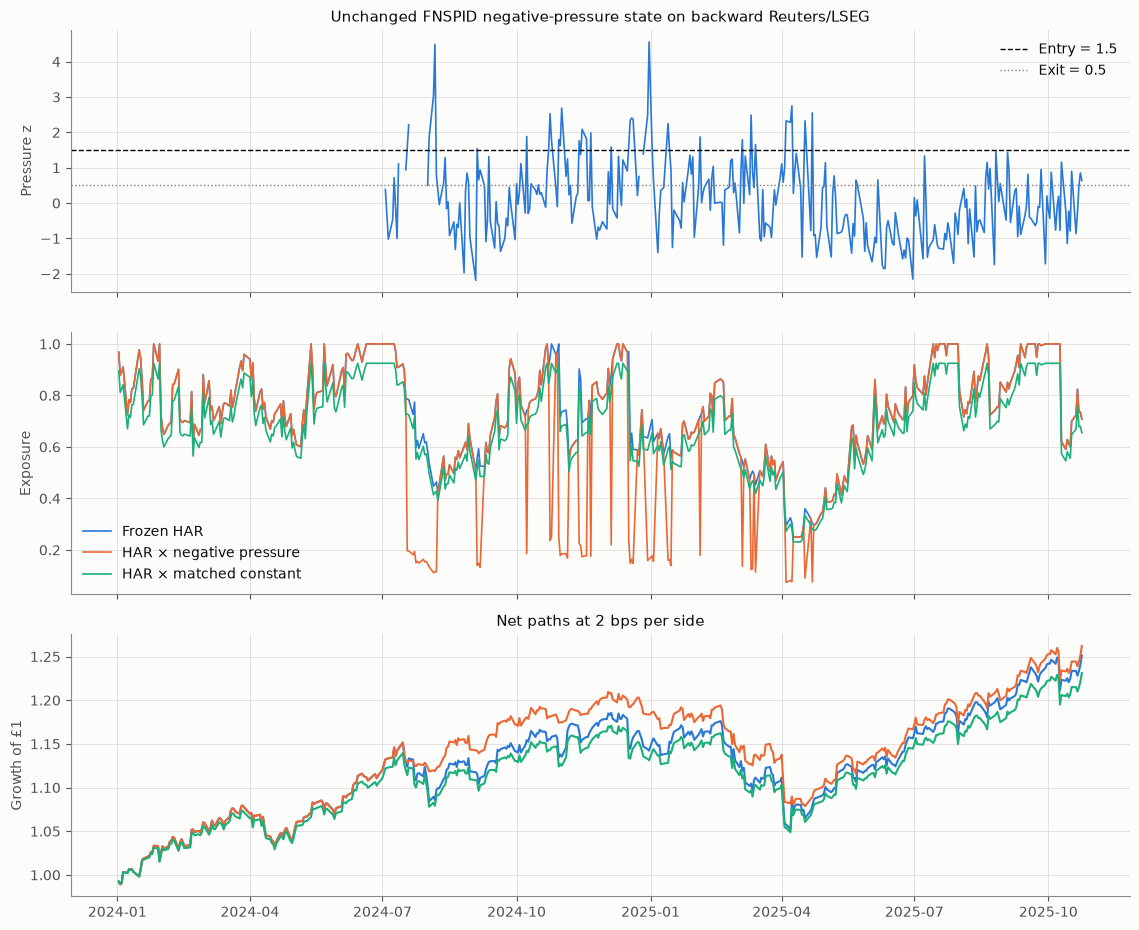

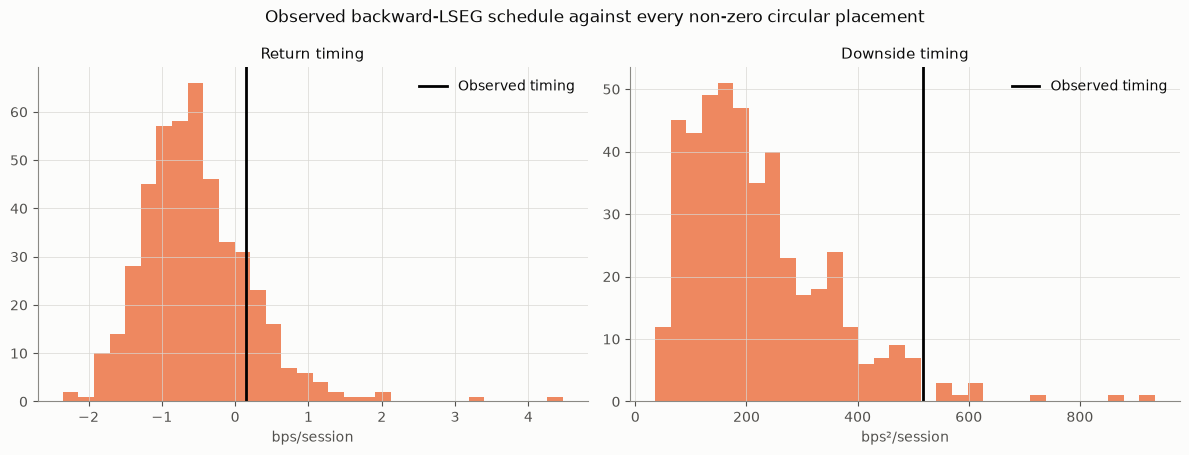

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.4), sharex=True)
axes[0].plot(
    state["session_date"],
    state["negative_pressure_z"],
    color=CATEGORICAL[0],
    linewidth=1.2,
)
axes[0].axhline(1.5, color="black", linestyle="--", linewidth=1.0, label="Entry = 1.5")
axes[0].axhline(0.5, color="grey", linestyle=":", linewidth=1.0, label="Exit = 0.5")
axes[0].set_ylabel("Pressure z")
axes[0].set_title("Unchanged FNSPID negative-pressure state on backward Reuters/LSEG")
axes[0].legend(loc="upper right")

for arm, label, colour in (
    ("frozen_har", "Frozen HAR", CATEGORICAL[0]),
    ("har_negative_pressure_overlay", "HAR × negative pressure", CATEGORICAL[1]),
    ("har_constant_matched_multiplier", "HAR × matched constant", CATEGORICAL[2]),
):
    exposure = exposures[arm]
    path = daily_paths[arm]
    axes[1].plot(
        exposure["session_date"],
        exposure["exposure"],
        label=label,
        color=colour,
        linewidth=1.2,
    )
    axes[2].plot(
        path["session_date"],
        (1.0 + path["net_return"]).cumprod(),
        label=label,
        color=colour,
        linewidth=1.5,
    )
axes[1].set_ylabel("Exposure")
axes[1].legend(loc="lower left")
axes[2].set_ylabel("Growth of £1")
axes[2].set_title("Net paths at 2 bps per side")
fig.tight_layout()
fig.savefig(OUTPUT / "pressure_exposure_and_equity.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
for axis, column, title, scale in (
    (axes[0], "mean_net_difference", "Return timing", 10_000),
    (axes[1], "downside_reduction", "Downside timing", 100_000_000),
):
    axis.hist(nonzero[column] * scale, bins=32, color=CATEGORICAL[1], alpha=0.78)
    axis.axvline(
        observed[column] * scale,
        color="black",
        linewidth=2,
        label="Observed timing",
    )
    axis.set_title(title)
    axis.set_xlabel("bps/session" if column == "mean_net_difference" else "bps²/session")
    axis.legend()
fig.suptitle("Observed backward-LSEG schedule against every non-zero circular placement")
fig.tight_layout()
fig.savefig(OUTPUT / "timing_placebo.png", dpi=180, bbox_inches="tight")
plt.show()

## Persist aggregate, licence-safe results

In [10]:
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
pressure_audit.to_csv(OUTPUT / "pressure_audit.csv", index=False)
pressure.to_parquet(OUTPUT / "daily_negative_pressure.parquet", index=False)
state.to_csv(OUTPUT / "backward_hysteresis_state.csv", index=False)
har_exposure.to_parquet(OUTPUT / "frozen_har_exposure.parquet", index=False)
results.to_csv(OUTPUT / "strategy_results.csv", index=False)
primary_inference.to_csv(OUTPUT / "primary_inference.csv", index=False)
matched_inference.to_csv(OUTPUT / "matched_exposure_inference.csv", index=False)
temporal.to_csv(OUTPUT / "temporal_results.csv", index=False)
incremental_halves.to_csv(OUTPUT / "incremental_halves.csv", index=False)
cost_curve.to_csv(OUTPUT / "cost_curve.csv", index=False)
shift_null.to_csv(OUTPUT / "circular_shift_null.csv", index=False)
timing_tests.to_csv(OUTPUT / "timing_tests.csv", index=False)
gates.to_csv(OUTPUT / "gates.csv", index=False)
for arm, path in daily_paths.items():
    path.to_parquet(OUTPUT / f"{arm}_daily.parquet", index=False)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
price_hashes = {
    str(PRICE_PATH.relative_to(ROOT)): sha256(PRICE_PATH),
    str(PRICE_MANIFEST_PATH.relative_to(ROOT)): sha256(PRICE_MANIFEST_PATH),
}
manifest = {
    "notebook": "73_lseg_negative_pressure_har_backward_transfer",
    "status": "complete_bounded_historical_cross_source_robustness",
    "git_commit_at_execution": git_commit,
    "frozen_spec": str(SPEC_PATH.relative_to(ROOT)),
    "pre_outcome_freeze_commit": "12086d5",
    "known_input_hashes": {
        str(path.relative_to(ROOT)): digest for path, digest in expected_known_hashes.items()
    },
    "acquired_price_hashes": price_hashes,
    "price_manifest": price_manifest,
    "sentiment_rule": spec["sentiment_rule"],
    "portfolio": spec["portfolio"],
    "pressure_audit": json.loads(pressure_audit.to_json(orient="records"))[0],
    "strategy_results": json.loads(results.to_json(orient="records")),
    "primary_inference": json.loads(primary_inference.to_json(orient="records")),
    "matched_exposure_inference": json.loads(matched_inference.to_json(orient="records")),
    "timing_tests": json.loads(timing_tests.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "claim_boundaries": spec["claim_boundaries"],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

display(
    Markdown(
        f"""### Decision

The exact backward-LSEG negative-pressure transfer **{'supports' if cross_source_support else 'does not support'}**
the FNSPID risk-timing mechanism under the frozen gates.

- Risk-off sessions: **{int(state['risk_off'].sum())}/{len(state)}** across
  **{int(state['risk_off_entry'].sum())}** entries.
- HAR net Sharpe: **{har_result['sharpe_net']:.3f}**.
- HAR × negative-pressure net Sharpe: **{overlay_result['sharpe_net']:.3f}**
  (change **{sharpe_improvement:+.3f}**).
- Exposure-matched constant net Sharpe: **{constant_result['sharpe_net']:.3f}**.
- Overlay-minus-HAR net return: **{return_test['mean'] * 10_000:+.3f} bps/session**
  (95% block interval **[{return_test['ci_low'] * 10_000:+.3f}, {return_test['ci_high'] * 10_000:+.3f}]**,
  BH q=**{return_test['q_bh_two_test']:.4f}**).
- HAR-minus-overlay downside squared return: **{downside_test['mean'] * 100_000_000:+.2f} bps²/session**
  (95% block interval **[{downside_test['ci_low'] * 100_000_000:+.2f}, {downside_test['ci_high'] * 100_000_000:+.2f}]**,
  BH q=**{downside_test['q_bh_two_test']:.4f}**).
- Circular-shift downside timing BH q: **{downside_timing['q_bh_two_test']:.4f}**.
- Gates — return: **{return_gate}**; useful risk: **{useful_risk_gate}**;
  timing: **{timing_gate}**; cross-source support: **{cross_source_support}**.

No threshold, scorer, window, cost, exposure parameter, inference family or gate
was changed after the historical index returns were acquired.
"""
    )
)

### Decision

The exact backward-LSEG negative-pressure transfer **does not support**
the FNSPID risk-timing mechanism under the frozen gates.

- Risk-off sessions: **53/456** across
  **18** entries.
- HAR net Sharpe: **1.291**.
- HAR × negative-pressure net Sharpe: **1.520**
  (change **+0.229**).
- Exposure-matched constant net Sharpe: **1.291**.
- Overlay-minus-HAR net return: **+0.144 bps/session**
  (95% block interval **[-1.295, +1.688]**,
  BH q=**0.8486**).
- HAR-minus-overlay downside squared return: **+517.41 bps²/session**
  (95% block interval **[+132.79, +984.35]**,
  BH q=**0.0336**).
- Circular-shift downside timing BH q: **0.0482**.
- Gates — return: **False**; useful risk: **False**;
  timing: **True**; cross-source support: **False**.

No threshold, scorer, window, cost, exposure parameter, inference family or gate
was changed after the historical index returns were acquired.


## Interpretation boundary

Report the backward and recent Reuters windows separately. A pass would be
bounded historical portability evidence, not prospective confirmation. A
failure is preserved and does not authorize threshold tuning.